# Traffic Accident Severity — Modelling & Evaluation
> Feature Selection via GridSearchCV · Models: Logistic Regression, SVM (Linear, Poly, RBF)

## 1. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model      import LogisticRegression
from sklearn.svm               import SVC
from sklearn.model_selection   import GridSearchCV, StratifiedKFold
from sklearn.metrics           import confusion_matrix, recall_score, classification_report

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [28]:
TARGET = 'accident_severity'

train = pd.read_csv('train_preprocessed.csv')
test  = pd.read_csv('test_preprocessed.csv')

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (6400, 20)
Test shape : (1600, 20)


## 3. Feature Selection using GridSearchCV
> `SelectKBest` + `LogisticRegression` inside a Pipeline. GridSearchCV finds the best number of features `k` by maximising macro recall over 5-fold cross-validation.

In [29]:
pipe = Pipeline([
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf',      LogisticRegression(max_iter=500, random_state=42))
])

n_features = X_train.shape[1]
param_grid = {'selector__k': list(range(1, n_features + 1))}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = pipe,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'recall_macro',
    n_jobs     = -1
)

grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['selector__k']
print(f'Best k              : {best_k}')
print(f'Best CV macro recall: {grid_search.best_score_:.4f}')

Best k              : 8
Best CV macro recall: 0.9494


In [30]:
# Extract selected features
best_selector  = grid_search.best_estimator_.named_steps['selector']
final_features = X_train.columns[best_selector.get_support()].tolist()

print(f'Selected {best_k} features:')
for f in final_features:
    print(' -', f)

X_train_sel = X_train[final_features]
X_test_sel  = X_test[final_features]

Selected 8 features:
 - speed_kmh
 - visibility_m
 - num_vehicles
 - alcohol_involved
 - seatbelt_worn
 - num_casualties
 - speed_excess_kmh
 - is_night


## 4. Modelling & Evaluation

In [31]:
CLASS_NAMES = ['Minor', 'Moderate', 'Severe']
results     = []

def evaluate(name, model):
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)

    print(f'\n{"-"*45}')
    print(f'  {name}')
    print(f'{"-"*45}')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Recall scores
    recall_per_class = recall_score(y_test, y_pred, average=None)
    macro_recall     = recall_score(y_test, y_pred, average='macro')
    for cls, r in zip(CLASS_NAMES, recall_per_class):
        print(f'  Recall ({cls:8s}): {r:.4f}')
    print(f'  Macro Recall     : {macro_recall:.4f}')

    results.append({'Model': name, 'Minor': recall_per_class[0],
                    'Moderate': recall_per_class[1], 'Severe': recall_per_class[2],
                    'Macro Recall': macro_recall})

print('evaluate() ready.')

evaluate() ready.


### 4.1 Logistic Regression


---------------------------------------------
  Logistic Regression
---------------------------------------------
              precision    recall  f1-score   support

       Minor       0.94      0.95      0.95       534
    Moderate       0.91      0.91      0.91       533
      Severe       0.97      0.96      0.97       533

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



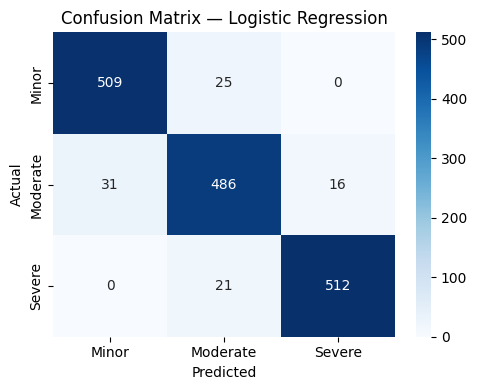

  Recall (Minor   ): 0.9532
  Recall (Moderate): 0.9118
  Recall (Severe  ): 0.9606
  Macro Recall     : 0.9419


In [32]:
evaluate('Logistic Regression',
         LogisticRegression(max_iter=1000, random_state=42))

### 4.2 SVM — Linear Kernel


---------------------------------------------
  SVM Linear
---------------------------------------------
              precision    recall  f1-score   support

       Minor       0.95      0.95      0.95       534
    Moderate       0.91      0.92      0.92       533
      Severe       0.97      0.96      0.97       533

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



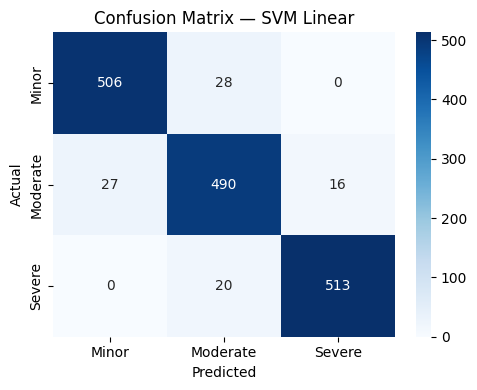

  Recall (Minor   ): 0.9476
  Recall (Moderate): 0.9193
  Recall (Severe  ): 0.9625
  Macro Recall     : 0.9431


In [33]:
evaluate('SVM Linear',
         SVC(kernel='linear', random_state=42))

### 4.3 SVM — Polynomial Kernel


---------------------------------------------
  SVM Polynomial
---------------------------------------------
              precision    recall  f1-score   support

       Minor       0.96      0.94      0.95       534
    Moderate       0.88      0.94      0.91       533
      Severe       0.98      0.93      0.96       533

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



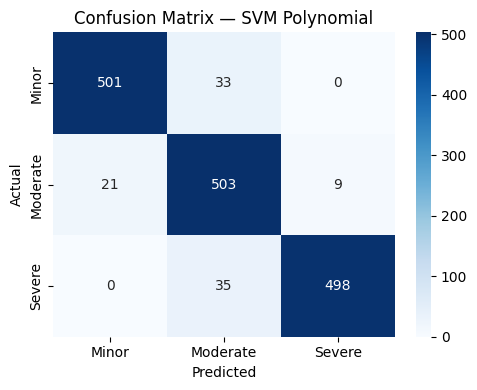

  Recall (Minor   ): 0.9382
  Recall (Moderate): 0.9437
  Recall (Severe  ): 0.9343
  Macro Recall     : 0.9388


In [34]:
evaluate('SVM Polynomial',
         SVC(kernel='poly', degree=3, random_state=42))

### 4.4 SVM — RBF Kernel


---------------------------------------------
  SVM RBF
---------------------------------------------
              precision    recall  f1-score   support

       Minor       0.96      0.95      0.95       534
    Moderate       0.91      0.93      0.92       533
      Severe       0.98      0.96      0.97       533

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



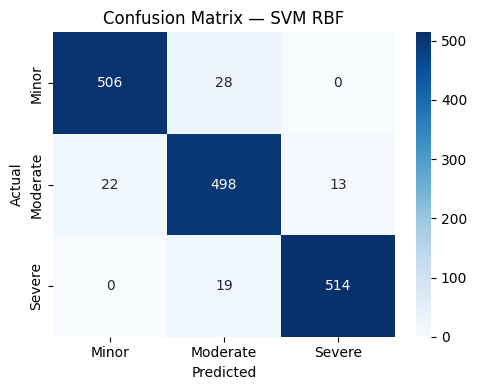

  Recall (Minor   ): 0.9476
  Recall (Moderate): 0.9343
  Recall (Severe  ): 0.9644
  Macro Recall     : 0.9488


In [35]:
evaluate('SVM RBF',
         SVC(kernel='rbf', random_state=42))

## 5. Model Comparison

In [36]:
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

best = results_df['Macro Recall'].idxmax()
print(f'\nBest Model: {best}  ({results_df.loc[best, "Macro Recall"]:.4f} macro recall)')

,Minor,Moderate,Severe,Macro Recall
Model,,,,
Logistic Regression,0.9532,0.9118,0.9606,0.9419
SVM Linear,0.9476,0.9193,0.9625,0.9431
SVM Polynomial,0.9382,0.9437,0.9343,0.9388
SVM RBF,0.9476,0.9343,0.9644,0.9488



Best Model: SVM RBF  (0.9488 macro recall)


In [37]:
# import pandas as pd
# import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm          import SVC
# from sklearn.metrics      import classification_report, recall_score
# import warnings
# warnings.filterwarnings('ignore')

# TARGET  = 'accident_severity'
# train   = pd.read_csv('train_preprocessed.csv')
# test    = pd.read_csv('test_preprocessed.csv')

# # ── Use your GridSearchCV selected features ───────────────────────────────
# selected_features = final_features   # from your GridSearchCV cell

# X_train = train[selected_features]
# y_train = train[TARGET]
# X_test  = test[selected_features]
# y_test  = test[TARGET]

# CLASS_NAMES  = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}
# BINARY_COLS  = ['alcohol_involved', 'seatbelt_worn', 'is_night']  # yes/no features

# # ── Feature info so user knows what to enter ──────────────────────────────
# FEATURE_HINTS = {
#     'alcohol_involved'     : '0 = No, 1 = Yes',
#     'seatbelt_worn'        : '0 = No, 1 = Yes',
#     'is_night'             : '0 = Day, 1 = Night',
#     'speed_kmh'            : 'speed in km/h  e.g. 80',
#     'speed_limit_kmh'      : 'speed limit in km/h  e.g. 60',
#     'speed_excess_kmh'     : 'how much over limit  e.g. 20',
#     'visibility_m'         : 'visibility in metres  e.g. 500',
#     'driver_age'           : 'age in years  e.g. 35',
#     'driver_experience_yrs': 'years of experience  e.g. 10',
#     'num_vehicles'         : 'number of vehicles involved  e.g. 2',
#     'num_casualties'       : 'number of casualties  e.g. 1',
#     'hour'                 : '0–23',
# }

# # ── Train all 4 models ────────────────────────────────────────────────────
# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'SVM Linear'         : SVC(kernel='linear',              random_state=42),
#     'SVM Polynomial'     : SVC(kernel='poly', degree=3,      random_state=42),
#     'SVM RBF'            : SVC(kernel='rbf',                 random_state=42),
# }

# print("Training models...")
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     print(f"  ✔ {name} trained")

# # ── Take input from user ──────────────────────────────────────────────────
# print("\n" + "="*50)
# print("  ENTER FEATURE VALUES FOR PREDICTION")
# print("="*50)

# user_input = {}
# for feat in selected_features:
#     hint = FEATURE_HINTS.get(feat, 'numeric value')
#     while True:
#         raw = input(f"  {feat}  ({hint}): ").strip().lower()
#         # handle yes/no
#         if raw in ['yes', 'y']:
#             raw = '1'
#         elif raw in ['no', 'n']:
#             raw = '0'
#         try:
#             user_input[feat] = float(raw)
#             break
#         except ValueError:
#             print(f"    ⚠ Invalid input, please enter a number.")

# input_df = pd.DataFrame([user_input])

# # ── Predict with all models ───────────────────────────────────────────────
# print("\n" + "="*50)
# print("  PREDICTION RESULTS")
# print("="*50)

# predictions = {}
# for name, model in models.items():
#     pred = model.predict(input_df)[0]
#     predictions[name] = CLASS_NAMES[pred]
#     print(f"  {name:<22} →  {CLASS_NAMES[pred]}")

# # ── Majority vote ─────────────────────────────────────────────────────────
# from collections import Counter
# vote = Counter(predictions.values()).most_common(1)[0][0]
# print(f"\n  Majority Vote Result  →  {vote}")
# print("="*50)

In [38]:
# import pandas as pd
# from sklearn.svm import SVC
# import warnings
# warnings.filterwarnings('ignore')

# TARGET = 'accident_severity'
# train  = pd.read_csv('train_preprocessed.csv')
# test   = pd.read_csv('test_preprocessed.csv')

# selected_features = final_features  # from your GridSearchCV cell

# X_train = train[selected_features]
# y_train = train[TARGET]

# CLASS_NAMES = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}

# FEATURE_HINTS = {
#     'alcohol_involved'     : '0 = No, 1 = Yes',
#     'seatbelt_worn'        : '0 = No, 1 = Yes',
#     'is_night'             : '0 = Day, 1 = Night',
#     'speed_kmh'            : 'speed in km/h  e.g. 80',
#     'speed_limit_kmh'      : 'speed limit in km/h  e.g. 60',
#     'speed_excess_kmh'     : 'how much over limit  e.g. 20',
#     'visibility_m'         : 'visibility in metres  e.g. 500',
#     'driver_age'           : 'age in years  e.g. 35',
#     'driver_experience_yrs': 'years of experience  e.g. 10',
#     'num_vehicles'         : 'number of vehicles involved  e.g. 2',
#     'num_casualties'       : 'number of casualties  e.g. 1',
#     'hour'                 : '0–23',
# }

# # ── Train SVM RBF ─────────────────────────────────────────────────────────
# model = SVC(kernel='rbf', random_state=42)
# model.fit(X_train, y_train)
# print("✔ SVM RBF trained")

# # ── Take input from user ──────────────────────────────────────────────────
# print("\n" + "="*50)
# print("  ENTER FEATURE VALUES FOR PREDICTION")
# print("="*50)

# user_input = {}
# for feat in selected_features:
#     hint = FEATURE_HINTS.get(feat, 'numeric value')
#     while True:
#         raw = input(f"  {feat}  ({hint}): ").strip().lower()
#         if raw in ['yes', 'y']:   raw = '1'
#         elif raw in ['no', 'n']:  raw = '0'
#         try:
#             user_input[feat] = float(raw)
#             break
#         except ValueError:
#             print("    ⚠ Invalid input, please enter a number.")

# input_df = pd.DataFrame([user_input])

# # ── Predict ───────────────────────────────────────────────────────────────
# pred = model.predict(input_df)[0]

# print("\n" + "="*50)
# print("  PREDICTION RESULT  (SVM RBF)")
# print("="*50)
# print(f"\n  Accident Severity  →  {CLASS_NAMES[pred]}\n")
# print("="*50)

In [39]:
# ── Run this cell in your notebook AFTER training all models ──────────────
# It saves the models + selected features so the Flask app can load them.

import joblib, json

joblib.dump(models['Logistic Regression'], 'model_lr.pkl')
joblib.dump(models['SVM Linear'],          'model_svm_linear.pkl')
joblib.dump(models['SVM Polynomial'],      'model_svm_poly.pkl')
joblib.dump(models['SVM RBF'],             'model_svm_rbf.pkl')

with open('selected_features.json', 'w') as f:
    json.dump(selected_features, f)

print("Models and features saved successfully.")
print("Selected features:", selected_features)

NameError: name 'models' is not defined

In [ ]:
import pickle
import numpy as np
import pandas as pd
from collections import Counter

# ── Config ───────────────────────────────────────────────────────────────────
MODELS = {
    '1': ('Logistic Regression', 'model_lr.pkl'),
    '2': ('SVM Linear',          'model_svm_linear.pkl'),
    '3': ('SVM Polynomial',      'model_svm_poly.pkl'),
    '4': ('SVM RBF',             'model_svm_rbf.pkl'),
}

SELECTED_FEATURES = [
    'speed_kmh', 'visibility_m', 'num_vehicles',
    'alcohol_involved', 'seatbelt_worn', 'num_casualties',
    'speed_excess_kmh', 'is_night'
]

FEATURE_HINTS = {
    'speed_kmh'       : 'speed in km/h  e.g. 80',
    'visibility_m'    : 'visibility in metres  e.g. 500',
    'num_vehicles'    : 'number of vehicles involved  e.g. 2',
    'alcohol_involved': '0 = No, 1 = Yes',
    'seatbelt_worn'   : '0 = No, 1 = Yes',
    'num_casualties'  : 'number of casualties  e.g. 1',
    'speed_excess_kmh': 'how much over limit  e.g. 20',
    'is_night'        : '0 = Day, 1 = Night',
}

LABEL_MAP = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}

# ── Preprocessing ─────────────────────────────────────────────────────────────
def preprocess(input_dict):
    return np.array([float(input_dict[f]) for f in SELECTED_FEATURES]).reshape(1, -1)

# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # 1. choose model (or 'all' for majority vote)
    print("\nSelect model:")
    for k, (name, _) in MODELS.items():
        print(f"  {k}. {name}")
    print("  5. All (majority vote)")
    choice = input("\nEnter choice (1-5): ").strip()

    # 2. take input
    print(f"\nEnter feature values:")
    user_input = {}
    for feat in SELECTED_FEATURES:
        hint = FEATURE_HINTS.get(feat, 'numeric value')
        while True:
            raw = input(f"  {feat}  ({hint}): ").strip().lower()
            if raw in ['yes', 'y']: raw = '1'
            elif raw in ['no', 'n']: raw = '0'
            try:
                user_input[feat] = float(raw)
                break
            except ValueError:
                print("    ⚠ Invalid input, please enter a number.")

    input_array = preprocess(user_input)

    # 3. predict
    print("\n" + "="*50)
    print("  PREDICTION RESULTS")
    print("="*50)

    if choice == '5':
        predictions = {}
        for name, path in MODELS.values():
            with open(path, 'rb') as f:
                model = pickle.load(f)
            pred = LABEL_MAP[model.predict(input_array)[0]]
            predictions[name] = pred
            print(f"  {name:<22} →  {pred}")
        vote = Counter(predictions.values()).most_common(1)[0][0]
        print(f"\n  Majority Vote Result  →  {vote}")
    else:
        model_name, model_path = MODELS[choice]
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
        pred = LABEL_MAP[model.predict(input_array)[0]]
        print(f"  {model_name:<22} →  {pred}")

    print("="*50)


Select model:
  1. Logistic Regression
  2. SVM Linear
  3. SVM Polynomial
  4. SVM RBF
  5. All (majority vote)

Enter feature values:
